In [59]:
import time
import csv
from pathlib import Path
from datetime import datetime

import numpy as np
import pyvisa
import matplotlib.pyplot as plt


In [60]:
from pathlib import Path
from datetime import datetime
import numpy as np

RESOURCE = "GPIB0::24::INSTR"

v_start = 0.0
v_stop = 200
n_points = 100
delay_s = 0.01

current_compliance = 1  # 10 mA

# Choose save folder (Downloads folder)
save_folder = Path.home() / "Downloads"
save_folder.mkdir(parents=True, exist_ok=True)

# ---- USER INPUT NAME ----
base_name = input("Enter filename (no extension): ").strip()

# Fallback if empty
if base_name == "":
    base_name = "iv_data"

# Timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Final filename: name + timestamp
save_filename = save_folder / f"{base_name}_{timestamp}.csv"

# Voltage array
voltages = np.linspace(v_start, v_stop, n_points)

print("Data will save to:")
print(save_filename)

Enter filename (no extension):  HL_30_T1+2_SPLE_50umconst_1000rpm_100mg_ml_D1_HV+COrr_405nm


Data will save to:
C:\Users\414824\Downloads\HL_30_T1+2_SPLE_50umconst_1000rpm_100mg_ml_D1_HV+COrr_405nm_20260521_170202.csv


In [61]:
rm = pyvisa.ResourceManager()

print("VISA backend:", rm.visalib)
print("Available resources:", rm.list_resources())

smu = rm.open_resource(RESOURCE)
smu.timeout = 10000
smu.write_termination = "\n"
smu.read_termination = "\n"
smu.write(":SENS:CURR:NPLC 5")

print("Connected to:", smu.query("*IDN?").strip())

VISA backend: Visa Library at C:\windows\system32\visa32.dll
Available resources: ('ASRL3::INSTR', 'GPIB0::24::INSTR')
Connected to: KEITHLEY INSTRUMENTS INC.,MODEL 2400,4313413,C34 Sep 21 2016 15:30:00/A02  /V/M


In [62]:
smu.write("*RST")
time.sleep(0.5)

smu.write(":SOUR:FUNC VOLT")
smu.write(":SOUR:VOLT:MODE FIX")
smu.write(":SENS:FUNC 'CURR'")
smu.write(f":SENS:CURR:PROT {current_compliance}")
smu.write(":FORM:ELEM VOLT,CURR")

print("Keithley initialized.")

Keithley initialized.


Run forward and backward sweep? (y/n):  y


Keithley output turned OFF.


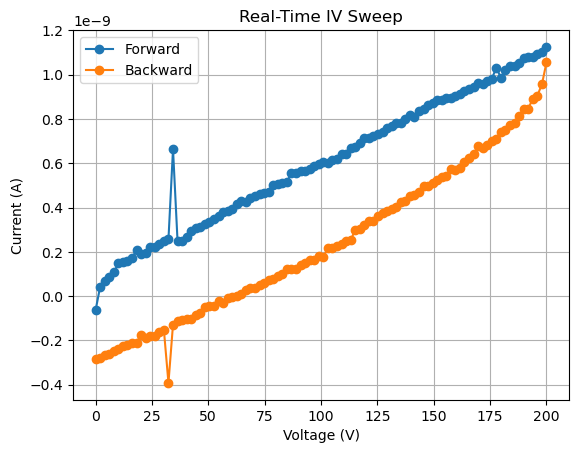

In [63]:
measured_v = []
measured_i = []
sweep_direction = []

forward_v = []
forward_i = []
backward_v = []
backward_i = []

# Ask whether to include backward sweep
answer = input("Run forward and backward sweep? (y/n): ").strip().lower()

if answer in ["y", "yes"]:
    forward_voltages = np.linspace(v_start, v_stop, n_points)
    backward_voltages = np.linspace(v_stop, v_start, n_points)
    sweep_voltages = np.concatenate([forward_voltages, backward_voltages])
    sweep_labels = ["forward"] * n_points + ["backward"] * n_points
else:
    sweep_voltages = np.linspace(v_start, v_stop, n_points)
    sweep_labels = ["forward"] * n_points

plt.ion()
fig, ax = plt.subplots()

# Two separate lines
forward_line, = ax.plot([], [], marker="o", label="Forward")
backward_line, = ax.plot([], [], marker="o", label="Backward")

ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Current (A)")
ax.set_title("Real-Time IV Sweep")
ax.grid(True)
ax.legend()

try:
    smu.write(":OUTP ON")

    for v, direction in zip(sweep_voltages, sweep_labels):
        smu.write(f":SOUR:VOLT {v}")
        time.sleep(delay_s)

        response = smu.query(":READ?").strip()
        vals = [float(x) for x in response.split(",")[:2]]

        measured_v.append(vals[0])
        measured_i.append(vals[1])
        sweep_direction.append(direction)

        if direction == "forward":
            forward_v.append(vals[0])
            forward_i.append(vals[1])
            forward_line.set_xdata(forward_v)
            forward_line.set_ydata(forward_i)
        else:
            backward_v.append(vals[0])
            backward_i.append(vals[1])
            backward_line.set_xdata(backward_v)
            backward_line.set_ydata(backward_i)

        ax.relim()
        ax.autoscale_view()
        fig.canvas.draw()
        fig.canvas.flush_events()

except Exception as e:
    print("Measurement error:", e)

finally:
    smu.write(":SOUR:VOLT 0")
    time.sleep(0.2)
    smu.write(":OUTP OFF")
    print("Keithley output turned OFF.")

In [64]:
if len(measured_v) == 0:
    print("No data to save. Run the measurement cell first.")
else:
    with open(save_filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["Voltage_V", "Current_A", "Sweep_Direction"])
        writer.writerows(zip(measured_v, measured_i, sweep_direction))

    print(f"Data saved to: {save_filename}")

Data saved to: C:\Users\414824\Downloads\HL_30_T1+2_SPLE_50umconst_1000rpm_100mg_ml_D1_HV+COrr_405nm_20260521_170202.csv


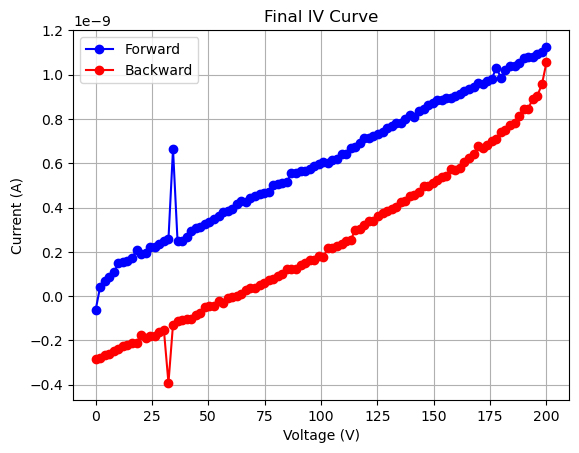

In [65]:
if len(measured_v) == 0:
    print("No data to plot. Run the measurement cell first.")
else:
    # Separate forward and backward data
    forward_data = [
        (v, i) for v, i, d in zip(measured_v, measured_i, sweep_direction)
        if d == "forward"
    ]

    backward_data = [
        (v, i) for v, i, d in zip(measured_v, measured_i, sweep_direction)
        if d == "backward"
    ]

    # Sort each sweep by voltage for cleaner plotting
    forward_data = sorted(forward_data, key=lambda x: x[0])
    backward_data = sorted(backward_data, key=lambda x: x[0])

    plt.figure()

    if len(forward_data) > 0:
        forward_v, forward_i = zip(*forward_data)
        plt.plot(forward_v, forward_i, marker="o", color="blue", label="Forward")

    if len(backward_data) > 0:
        backward_v, backward_i = zip(*backward_data)
        plt.plot(backward_v, backward_i, marker="o", color="red", label="Backward")

    plt.xlabel("Voltage (V)")
    plt.ylabel("Current (A)")
    plt.title("Final IV Curve")
    plt.grid(True)
    plt.legend()
    plt.show()

In [66]:
smu.write(":SOUR:VOLT 0")
smu.write(":OUTP OFF")
print("Keithley output OFF.")

Keithley output OFF.
